# Clinical Outcomes Predictor (Healthcare ML)
**Goal:** Build a baseline stroke-risk screening model and present results in a clear, decision-ready way.

**Why this matters:** Stroke is a rare outcome in this dataset. In screening use-cases, accuracy can be misleading. We focus on recall (catching true stroke cases) and probability-based evaluation.

**Dataset:** `stroke.csv` (public dataset)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("stroke.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


## 1) Data overview & quality checks
We review schema, basic distributions, and missing values.  
Key issues in this dataset:
- `bmi` has missing values
- `smoking_status` has many missing values

In [4]:
display(df.info())
display(df.describe(include="all"))

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "missing_%": missing_pct})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


None

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,43400.000000,43400,43400.000000,43400.000000,43400.000000,43400,43400,43400,43400.000000,41938.000000,30108,43400.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,3,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,25665,NaN,NaN,NaN,27938,24834,21756,NaN,NaN,16053,NaN
mean,36326.142350,NaN,42.217894,0.093571,0.047512,NaN,NaN,NaN,104.482750,28.605038,NaN,0.018041
std,21072.134879,NaN,22.519649,0.291235,0.212733,NaN,NaN,NaN,43.111751,7.770020,NaN,0.133103
min,1.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.000000,10.100000,NaN,0.000000
25%,18038.500000,NaN,24.000000,0.000000,0.000000,NaN,NaN,NaN,77.540000,23.200000,NaN,0.000000
50%,36351.500000,NaN,44.000000,0.000000,0.000000,NaN,NaN,NaN,91.580000,27.700000,NaN,0.000000
75%,54514.250000,NaN,60.000000,0.000000,0.000000,NaN,NaN,NaN,112.070000,32.900000,NaN,0.000000


,missing,missing_%
smoking_status,13292,30.63
bmi,1462,3.37
id,0,0.00
gender,0,0.00
age,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
ever_married,0,0.00
work_type,0,0.00
Residence_type,0,0.00


In [5]:
# Clean missing values in a simple, transparent way
df = df.copy()

# Drop rare category "Other" in gender (tiny count, avoids noise)
df = df[df["gender"] != "Other"]

# Fill BMI with median (robust and removes pandas warning)
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# Make smoking_status missing explicit
df["smoking_status"] = df["smoking_status"].fillna("Unknown")

df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

## 2) Quick insights (EDA)
Two fast visuals that communicate the problem:
1) Stroke is rare → imbalance matters  
2) Age tends to be higher in stroke cases

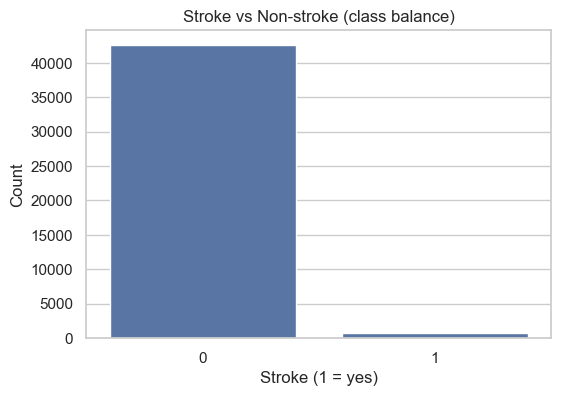

Stroke rate: 1.8 %


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x="stroke", data=df)
plt.title("Stroke vs Non-stroke (class balance)")
plt.xlabel("Stroke (1 = yes)")
plt.ylabel("Count")
plt.show()

print("Stroke rate:", round(df["stroke"].mean() * 100, 2), "%")

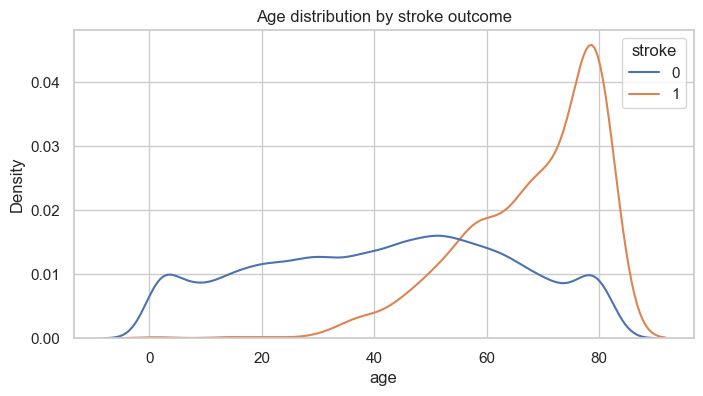

In [7]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x="age", hue="stroke", common_norm=False)
plt.title("Age distribution by stroke outcome")
plt.show()

## 3) Baseline feature prep
We keep preprocessing simple and interpretable:
- Encode categorical variables
- Create one additional interaction feature (age × glucose) to demonstrate feature engineering

In [8]:
df_model = df.copy()

# Label encoding is OK for a baseline, but note: for production we'd one-hot encode.
le = LabelEncoder()
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Simple engineered feature
df_model["age_glucose_interaction"] = df_model["age"] * df_model["avg_glucose_level"]

X = df_model.drop(["id", "stroke"], axis=1)
y = df_model["stroke"]

X.head(), y.value_counts()

(   gender   age  hypertension  heart_disease  ever_married  work_type  \
 0       1   3.0             0              0             0          4   
 1       1  58.0             1              0             1          2   
 2       0   8.0             0              0             0          2   
 3       0  70.0             0              0             1          2   
 4       1  14.0             0              0             0          1   
 
    Residence_type  avg_glucose_level   bmi  smoking_status  \
 0               0              95.12  18.0               0   
 1               1              87.96  39.2               2   
 2               1             110.89  17.6               0   
 3               0              69.04  35.9               1   
 4               0             161.28  19.1               0   
 
    age_glucose_interaction  
 0                   285.36  
 1                  5101.68  
 2                   887.12  
 3                  4832.80  
 4                  2257

## 4) Train/test split (important)
We split FIRST, then apply SMOTE only on the training data.  
This avoids making the evaluation look unrealistically good.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Train class balance before SMOTE:\n", y_train.value_counts(normalize=True).round(4))
print("\nTrain class balance after SMOTE:\n", y_train_res.value_counts(normalize=True).round(4))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(4))

Train class balance before SMOTE:
 stroke
0    0.982
1    0.018
Name: proportion, dtype: float64

Train class balance after SMOTE:
 stroke
0    0.5
1    0.5
Name: proportion, dtype: float64

Test class balance:
 stroke
0    0.9819
1    0.0181
Name: proportion, dtype: float64


## 5) Model training (Logistic Regression baseline)
Logistic regression is interpretable and a strong baseline for healthcare-style screening.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train_res)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## 6) Evaluation (business-ready)
Because stroke is rare, accuracy can be misleading.  
We include:
- Confusion matrix
- Classification report
- ROC curve (general)
- Precision–Recall curve (often more meaningful for rare outcomes)

In [12]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

Accuracy: 0.7861

Confusion Matrix:
 [[6724 1797]
 [  59   98]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9913    0.7891    0.8787      8521
           1     0.0517    0.6242    0.0955       157

    accuracy                         0.7861      8678
   macro avg     0.5215    0.7067    0.4871      8678
weighted avg     0.9743    0.7861    0.8646      8678



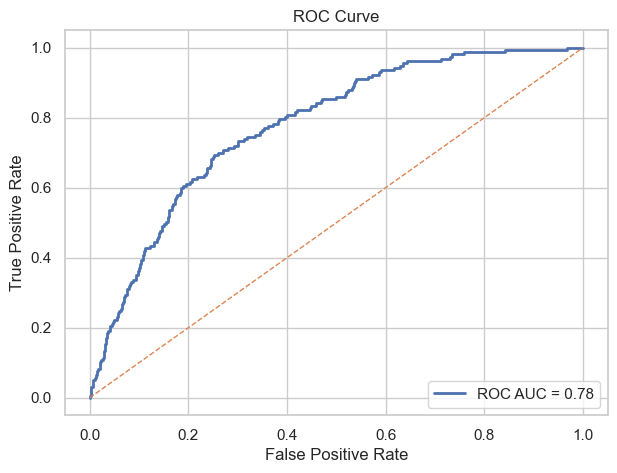

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2, label=f"ROC AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

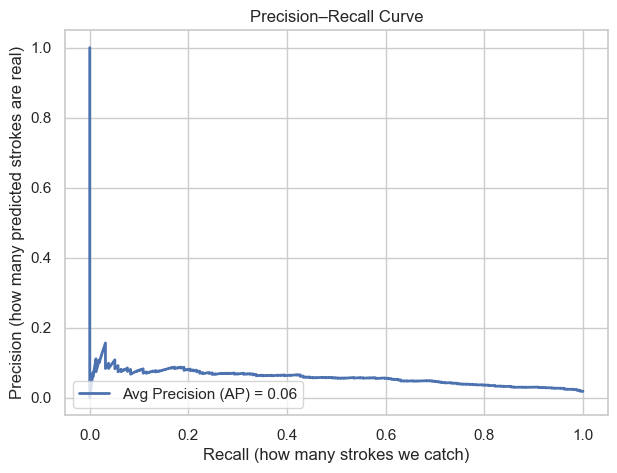

In [14]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, lw=2, label=f"Avg Precision (AP) = {ap:.2f}")
plt.xlabel("Recall (how many strokes we catch)")
plt.ylabel("Precision (how many predicted strokes are real)")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.show()

## 7) Simple threshold table (decision support)
In screening, we may choose a lower threshold than 0.5 to catch more stroke cases (higher recall),
accepting more false positives.

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

def metrics_at_threshold(th):
    pred = (y_prob >= th).astype(int)
    return {
        "threshold": th,
        "precision(stroke)": precision_score(y_test, pred, zero_division=0),
        "recall(stroke)": recall_score(y_test, pred, zero_division=0),
        "f1(stroke)": f1_score(y_test, pred, zero_division=0),
        "positives_flagged_%": pred.mean() * 100
    }

thresholds = [0.2, 0.3, 0.5]
pd.DataFrame([metrics_at_threshold(t) for t in thresholds]).round(3)

,threshold,precision(stroke),recall(stroke),f1(stroke),positives_flagged_%
0,0.2,0.035,0.809,0.067,42.199
1,0.3,0.040,0.745,0.075,34.075
2,0.5,0.052,0.624,0.096,21.837


## 8) Model interpretability (feature importance)
For logistic regression, coefficient magnitude gives an interpretable view of key drivers.

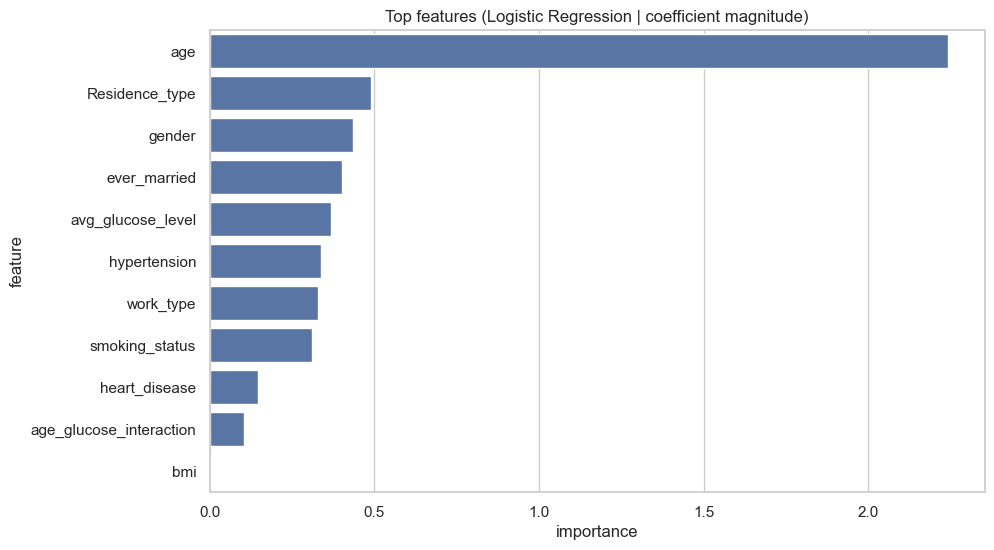

,feature,importance
1,age,2.240291
6,Residence_type,0.489662
0,gender,0.434344
4,ever_married,0.402979
7,avg_glucose_level,0.367524
2,hypertension,0.339631
5,work_type,0.329626
9,smoking_status,0.312571
3,heart_disease,0.147250
10,age_glucose_interaction,0.103556


In [17]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": np.abs(model.coef_[0])
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(12), x="importance", y="feature")
plt.title("Top features (Logistic Regression | coefficient magnitude)")
plt.show()

feature_importance.head(12)

## Summary & next steps
**What this notebook delivers**
- Clear baseline model for stroke-risk screening (interpretable logistic regression)
- Evaluation suited for rare outcomes (Precision–Recall + threshold table)
- Key drivers surfaced for discussion

**Next steps (if this were a real product)**
- Replace label encoding with one-hot encoding for categories
- Compare to a tree-based model (e.g., Gradient Boosting)
- Add calibration (probabilities that match reality)
- Deploy as a small screening demo app 